<a href="https://colab.research.google.com/github/raniyaarani13-web/north-star-analytics/blob/main/DBA_assignment_R_Raniya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Raniya Kunnumpuram Batch 2
#32146993
#NorthStar Urban Mobility - R Analytics Notebook
#SQL in R using sqldf + R Analytics and Visualisation

In [1]:
# Install required packages
install.packages("sqldf")
install.packages("RCurl")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyverse")

# Load libraries
library(sqldf)
library(RCurl)
library(ggplot2)
library(dplyr)
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘bitops’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ 

In [2]:
#Load all datasets from GitHub

base_url <- "https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/"

customers <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/customers.csv")
orders <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/orders.csv")
deliveries <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/deliveries.csv")
drivers <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/drivers.csv")
vehicles <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/vehicles.csv")
hubs <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/hubs.csv")
incidents <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/incidents.csv")
complaints <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/complaints.csv")
app_events <- read.csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/app_events.csv")

# Confirm loading
cat("Datasets loaded successfully!\n")
cat("Customers:", nrow(customers), "rows\n")
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")
cat("Drivers:", nrow(drivers), "rows\n")
cat("Vehicles:", nrow(vehicles), "rows\n")
cat("Hubs:", nrow(hubs), "rows\n")
cat("Incidents:", nrow(incidents), "rows\n")
cat("Complaints:", nrow(complaints), "rows\n")
cat("App Events:", nrow(app_events), "rows\n")

Datasets loaded successfully!
Customers: 650 rows
Orders: 1250 rows
Deliveries: 950 rows
Drivers: 170 rows
Vehicles: 120 rows
Hubs: 8 rows
Incidents: 280 rows
Complaints: 320 rows
App Events: 640 rows


In [ ]:
#Data Overview and Structure

# Inspect customers dataset structure
cat("CUSTOMERS STRUCTURE:\n")
glimpse(customers)
summary(customers)

CUSTOMERS STRUCTURE
Rows: 650
Columns: 9
$ customer_id          <chr> "C0001", "C0002", "C0003", "C0004", "C0005", "C00…
$ age                  <int> 26, 61, 66, 75, 26, 41, 54, 70, 34, 23, 49, 60, 3…
$ home_zone            <chr> "North", "AIRPORT", "East", "CENTRAL", "Riverside…
$ customer_type        <chr> "SME", "Consumer", "Consumer", "Consumer", "Consu…
$ signup_date          <chr> "27/11/2024 4:25", "28/10/2025 1:04", "02/07/2025…
$ loyalty_score        <dbl> 44.9, 55.4, 75.9, 32.5, 55.9, 39.9, 36.1, 84.6, 6…
$ app_engagement_score <dbl> 69.2, 66.6, 33.8, 33.0, 100.0, 43.3, 39.0, 65.2, …
$ preferred_channel    <chr> "App", "App", "", "App", "Web", "Web", "App", "We…
$ account_status       <chr> "Active", "Active", "Active", "Active", "Active",…


    customer_id       age            home_zone     customer_type
 Length   :650   Min.   :18.00   Length   :650   Length   :650  
 N.unique :650   1st Qu.:32.00   N.unique : 16   N.unique :  3  
 N.blank  :  0   Median :46.00   N.blank  :  0   N.blank  :  0  
 Min.nchar:  5   Mean   :46.74   Min.nchar:  3   Min.nchar:  3  
 Max.nchar:  5   3rd Qu.:62.00   Max.nchar:  9   Max.nchar: 10  
                 Max.   :78.00                                  
                                                                
    signup_date  loyalty_score   app_engagement_score preferred_channel
 Length   :650   Min.   :13.10   Min.   :  1.00       Length   :650    
 N.unique :650   1st Qu.:49.00   1st Qu.: 45.38       N.unique :  5    
 N.blank  :  0   Median :59.60   Median : 59.00       N.blank  : 13    
 Min.nchar: 15   Mean   :59.69   Mean   : 58.13       Min.nchar:  0    
 Max.nchar: 16   3rd Qu.:70.45   3rd Qu.: 72.00       Max.nchar: 11    
                 Max.   :99.00   Max.   :100.00 

In [ ]:
# Inspect orders dataset structure
cat("ORDERS STRUCTURE:\n")
glimpse(orders)
summary(orders)

ORDERS STRUCTURE:
Rows: 1,250
Columns: 11
$ order_id              <chr> "O00001", "O00002", "O00003", "O00004", "O00005"…
$ customer_id           <chr> "C0292", "C0459", "C0161", "C0520", "C0558", "C0…
$ service_type          <chr> "Passenger", "Passenger", "Passenger", "Parcel",…
$ order_created_at      <chr> "20/08/2024 14:43", "14/05/2024 22:16", "02/09/2…
$ promised_window_hours <int> 6, 24, 4, 2, 12, 1, 2, 4, 12, 6, 12, 12, 24, 6, …
$ pickup_zone           <chr> "Airport", "North", "West", "RiverSide", "Rivers…
$ dropoff_zone          <chr> "South", "AIRPORT", "AIRPORT", "North", "SOUTH",…
$ priority_level        <chr> "Medium", "Low", "High", "Medium", "Low", "High"…
$ order_value           <dbl> 126.65, 109.30, 33.50, 10.04, 125.58, 151.44, 76…
$ booking_channel       <chr> "App", "App", "Phone", "App", "Phone", "Web", "A…
$ special_handling_flag <int> 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


      order_id       customer_id      service_type   order_created_at
 Length   :1250   Length   :1250   Length   :1250   Length   :1250   
 N.unique :1250   N.unique : 568   N.unique :   5   N.unique :1248   
 N.blank  :   0   N.blank  :   0   N.blank  :   0   N.blank  :   0   
 Min.nchar:   6   Min.nchar:   5   Min.nchar:   6   Min.nchar:  15   
 Max.nchar:   6   Max.nchar:   5   Max.nchar:   9   Max.nchar:  16   
                                                                     
 promised_window_hours    pickup_zone      dropoff_zone    priority_level
 Min.   : 1.000        Length   :1250   Length   :1250   Length   :1250  
 1st Qu.: 4.000        N.unique :  16   N.unique :  16   N.unique :   4  
 Median : 6.000        N.blank  :   0   N.blank  :   0   N.blank  :   0  
 Mean   : 7.622        Min.nchar:   3   Min.nchar:   3   Min.nchar:   3  
 3rd Qu.:12.000        Max.nchar:   9   Max.nchar:   9   Max.nchar:   8  
 Max.   :24.000                                                   

In [ ]:
# Inspect deliveries dataset structure
cat("DELIVERIES STRUCTURE:\n")
glimpse(deliveries)
summary(deliveries)

DELIVERIES STRUCTURE:
Rows: 950
Columns: 13
$ delivery_id                   <chr> "DL00001", "DL00002", "DL00003", "DL0000…
$ order_id                      <chr> "O00938", "O00004", "O00639", "O00313", …
$ driver_id                     <chr> "D004", "D138", "D006", "D116", "D108", …
$ vehicle_id                    <chr> "V056", "V007", "V049", "V055", "V034", …
$ hub_id                        <chr> "H05", "H02", "H02", "H02", "H01", "H03"…
$ dispatch_time                 <chr> "18/06/2024 10:57", "11/01/2025 18:45", …
$ delivery_completed_at         <chr> "05:59.9", "39:00.0", "45:32.4", "30:08.…
$ delivery_status               <chr> "Failed", "OnTime", "OnTime", "Delayed",…
$ route_distance_km             <dbl> 17.26, 10.34, 7.92, 16.42, 14.52, 13.84,…
$ manual_route_override_count   <int> 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 3, 2, 0…
$ proof_of_completion_missing   <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ customer_rating_post_delivery <dbl> 3.07, 5.00, 4.98, 4.18, 4.18, 1.57, 4.

    delivery_id       order_id       driver_id       vehicle_id 
 Length   :950   Length   :950   Length   :950   Length   :950  
 N.unique :950   N.unique :950   N.unique :170   N.unique :120  
 N.blank  :  0   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Min.nchar:  7   Min.nchar:  6   Min.nchar:  4   Min.nchar:  4  
 Max.nchar:  7   Max.nchar:  6   Max.nchar:  4   Max.nchar:  4  
                                                                
                                                                
       hub_id      dispatch_time delivery_completed_at  delivery_status
 Length   :950   Length   :950   Length   :950         Length   :950   
 N.unique :  8   N.unique :950   N.unique :911         N.unique :  3   
 N.blank  :  0   N.blank  :  0   N.blank  : 19         N.blank  :  0   
 Min.nchar:  3   Min.nchar: 15   Min.nchar:  0         Min.nchar:  6   
 Max.nchar:  3   Max.nchar: 16   Max.nchar:  7         Max.nchar:  7   
                                                

In [ ]:
#Data Cleaning

# Standardise zone names to title case (fix inconsistency)
customers$home_zone <- stringr::str_to_title(trimws(customers$home_zone))
orders$pickup_zone <- stringr::str_to_title(trimws(orders$pickup_zone))
orders$dropoff_zone <- stringr::str_to_title(trimws(orders$dropoff_zone))

# Fix "Ctr" and "Riverside" variations to standard names
customers$home_zone <- gsub("Ctr", "Central", customers$home_zone)
customers$home_zone <- gsub("Riverside", "Riverside", customers$home_zone)
orders$pickup_zone <- gsub("Ctr", "Central", orders$pickup_zone)
orders$dropoff_zone <- gsub("Ctr", "Central", orders$dropoff_zone)

# Handle missing loyalty scores - replace NA with median
customers$loyalty_score[is.na(customers$loyalty_score)] <- median(customers$loyalty_score, na.rm = TRUE)

# Handle missing customer ratings - replace NA with median
deliveries$customer_rating_post_delivery[is.na(deliveries$customer_rating_post_delivery)] <- median(deliveries$customer_rating_post_delivery, na.rm = TRUE)

# Replace blank preferred_channel with "Unknown"
customers$preferred_channel[customers$preferred_channel == ""] <- "Unknown"

# Confirm cleaning
cat("Missing loyalty scores after cleaning:", sum(is.na(customers$loyalty_score)), "\n")
cat("Missing ratings after cleaning:", sum(is.na(deliveries$customer_rating_post_delivery)), "\n")
cat("Unique home zones after cleaning:", length(unique(customers$home_zone)), "\n")
cat("Data cleaning complete!\n")

Missing loyalty scores after cleaning: 0 
Missing ratings after cleaning: 0 
Unique home zones after cleaning: 7 
Data cleaning complete!


Q1: Number of Customers per Zone
   home_zone customer_count
1      SOUTH             50
2  RiverSide             49
3       East             48
4       WEST             45
5    CENTRAL             44
6       West             43
7      South             42
8  Riverside             42
9       EAST             41
10     north             39
11     North             39
12   Airport             35
13   AIRPORT             34
14     NORTH             33
15       Ctr             33
16   Central             33


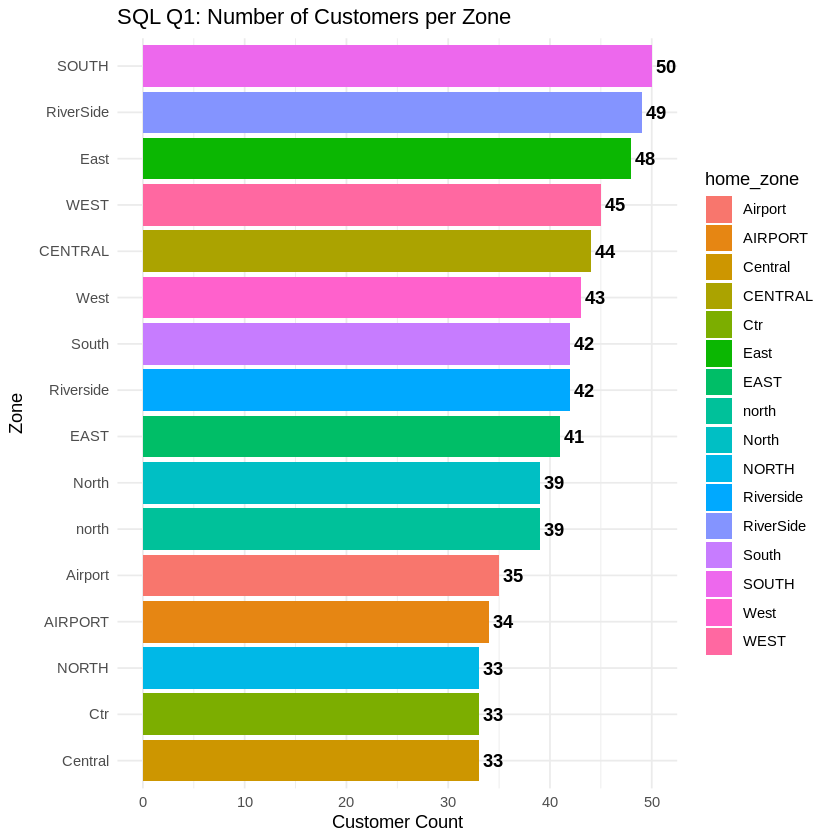

In [13]:
#SQL Queries in R using sqldf

#SQL Query 1: Count customers by zone
cat("Q1: Number of Customers per Zone\n")
q1 <- sqldf("SELECT home_zone, COUNT(*) AS customer_count
             FROM customers
             GROUP BY home_zone
             ORDER BY customer_count DESC")
print(q1)

ggplot(q1, aes(x = reorder(home_zone, customer_count),
               y = customer_count, fill = home_zone)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "SQL Q1: Number of Customers per Zone",
       x = "Zone", y = "Customer Count") +
  theme_minimal() +
  geom_text(aes(label = customer_count), hjust = -0.2, fontface = "bold")


Q2: Average Loyalty Score by Customer Type
  customer_type avg_loyalty avg_engagement total_customers
1      Consumer       60.32          58.56             476
2    Enterprise       59.33          55.17              50
3           SME       57.35          57.69             124


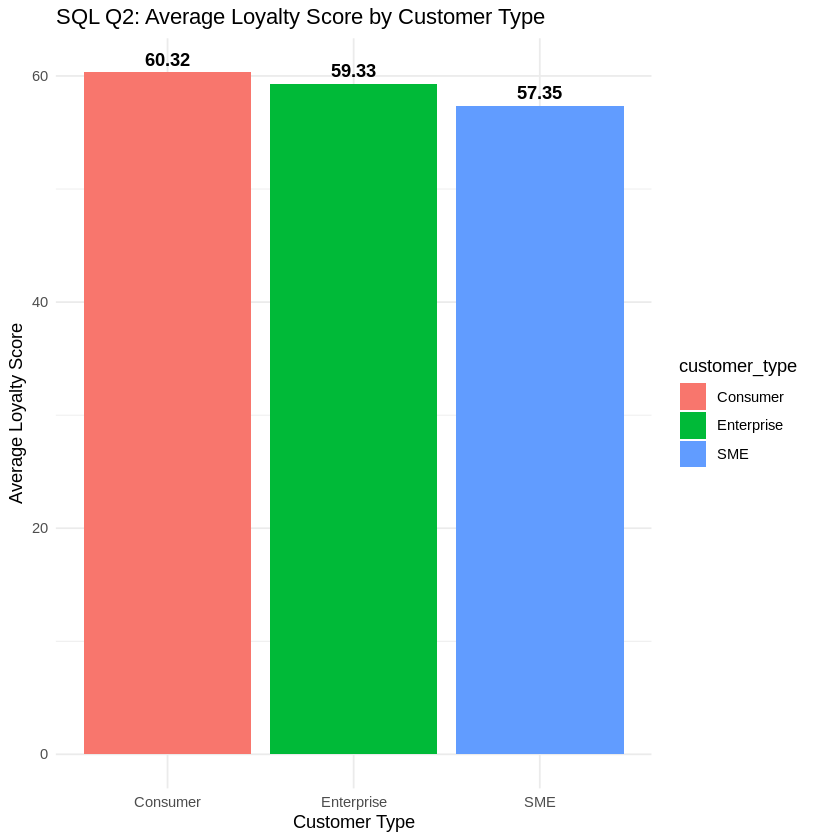

In [4]:
#SQL Query 2: Average loyalty score by customer type
cat("\nQ2: Average Loyalty Score by Customer Type\n")
q2 <- sqldf("SELECT customer_type,
             ROUND(AVG(loyalty_score), 2) AS avg_loyalty,
             ROUND(AVG(app_engagement_score), 2) AS avg_engagement,
             COUNT(*) AS total_customers
             FROM customers
             GROUP BY customer_type
             ORDER BY avg_loyalty DESC")
print(q2)

ggplot(q2, aes(x = customer_type, y = avg_loyalty, fill = customer_type)) +
  geom_bar(stat = "identity") +
  labs(title = "SQL Q2: Average Loyalty Score by Customer Type",
       x = "Customer Type", y = "Average Loyalty Score") +
  theme_minimal() +
  geom_text(aes(label = avg_loyalty), vjust = -0.5, fontface = "bold")


Q3: Total Orders and Revenue by Service Type
  service_type total_orders total_revenue avg_order_value
1    Passenger          341      32761.11           96.07
2       Parcel          308      26985.62           87.62
3       Retail          297      26734.06           90.01
4     Business          165      15220.43           92.25
5      Medical          139      12111.93           87.14


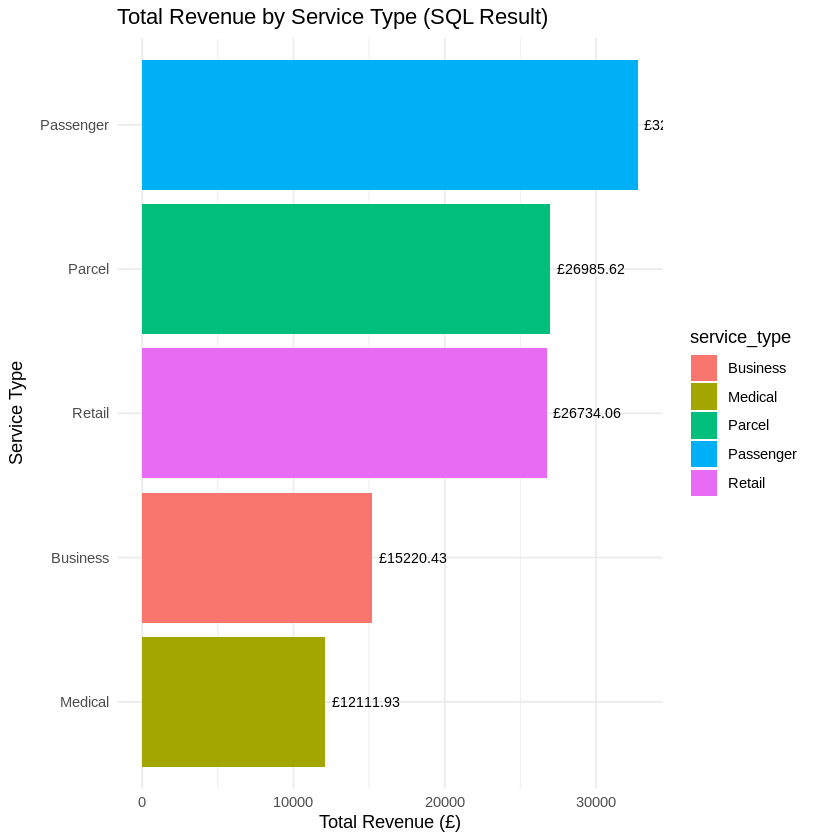

In [5]:
#SQL Query 3: Orders by service type
cat("\nQ3: Total Orders and Revenue by Service Type\n")
q3 <- sqldf("SELECT service_type,
             COUNT(*) AS total_orders,
             ROUND(SUM(order_value), 2) AS total_revenue,
             ROUND(AVG(order_value), 2) AS avg_order_value
             FROM orders
             GROUP BY service_type
             ORDER BY total_revenue DESC")
print(q3)

# Visualisation for SQL Q3: Revenue by Service Type
ggplot(q3, aes(x = reorder(service_type, total_revenue),
               y = total_revenue, fill = service_type)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Total Revenue by Service Type (SQL Result)",
       x = "Service Type", y = "Total Revenue (£)") +
  theme_minimal() +
  geom_text(aes(label = paste0("£", total_revenue)),
            hjust = -0.1, size = 3)


Q4: Delivery Status Breakdown
  delivery_status count avg_rating avg_distance
1          OnTime   616       4.28        13.78
2         Delayed   202       3.11        14.67
3          Failed   132       3.05        13.37


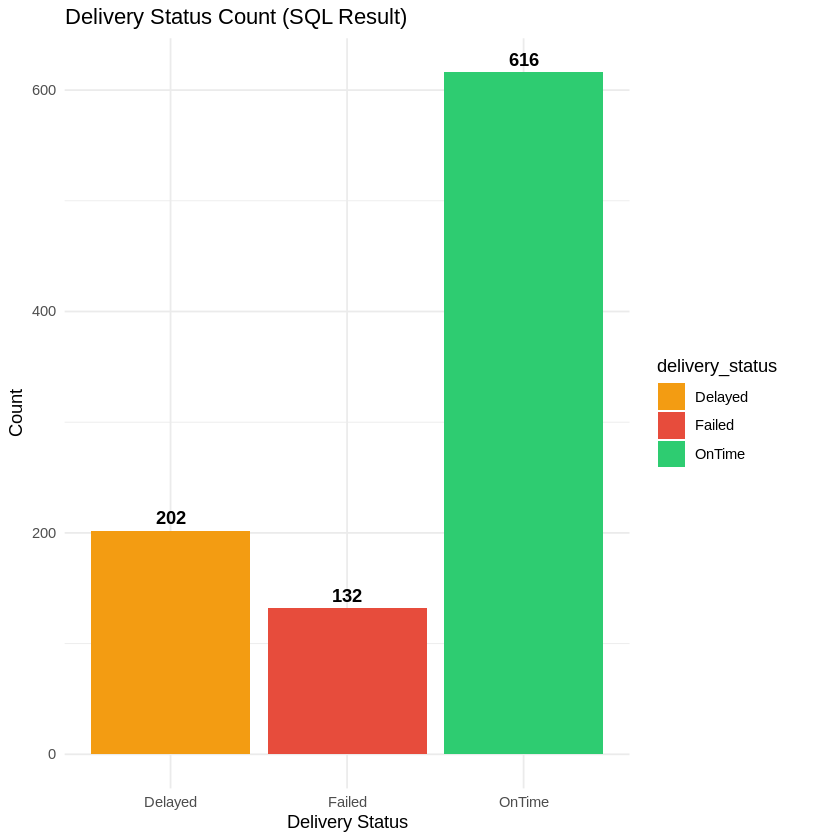

In [6]:
#SQL Query 4: Delivery status breakdown
cat("\nQ4: Delivery Status Breakdown\n")
q4 <- sqldf("SELECT delivery_status,
             COUNT(*) AS count,
             ROUND(AVG(customer_rating_post_delivery), 2) AS avg_rating,
             ROUND(AVG(route_distance_km), 2) AS avg_distance
             FROM deliveries
             GROUP BY delivery_status
             ORDER BY count DESC")
print(q4)

# Visualisation for SQL Q4: Delivery Status
ggplot(q4, aes(x = delivery_status, y = count, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  labs(title = "Delivery Status Count (SQL Result)",
       x = "Delivery Status", y = "Count") +
  theme_minimal() +
  scale_fill_manual(values = c("OnTime" = "#2ecc71",
                                "Delayed" = "#f39c12",
                                "Failed" = "#e74c3c")) +
  geom_text(aes(label = count), vjust = -0.5, fontface = "bold")


Q5: Deliveries per Hub
  hub_id total_deliveries avg_rating missing_proofs
1    H01              136       3.84              6
2    H08              128       3.88             10
3    H04              127       3.92              7
4    H03              119       3.90              9
5    H07              115       3.88              9
6    H05              115       3.67             10
7    H02              106       3.95              8
8    H06              104       3.88             10


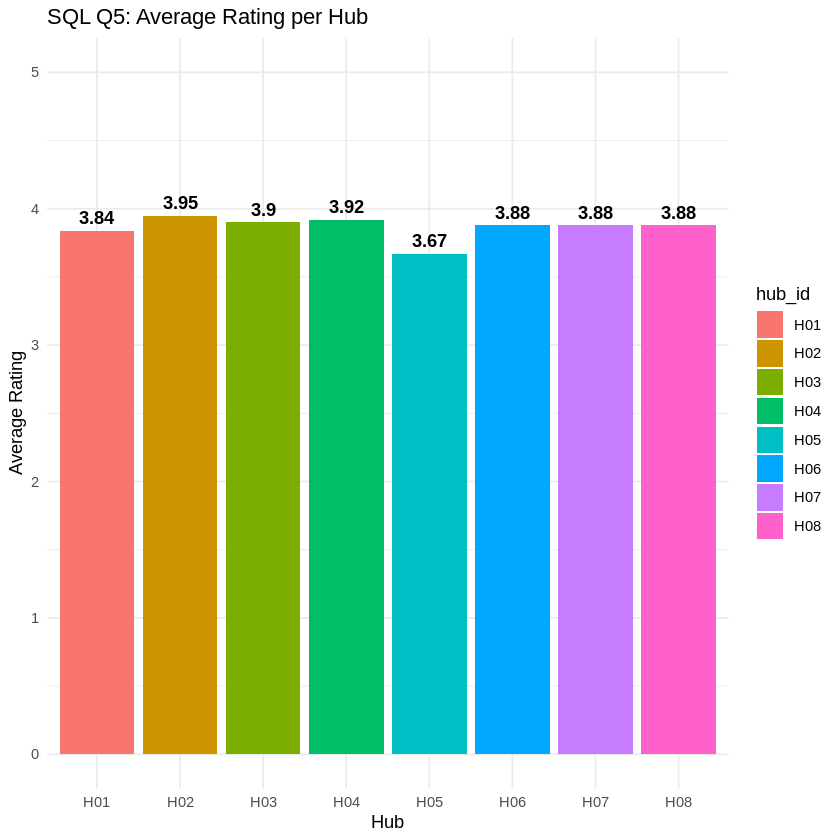

In [7]:
#SQL Query 5: Top 5 hubs by number of deliveries
cat("\nQ5: Deliveries per Hub\n")
q5 <- sqldf("SELECT hub_id,
             COUNT(*) AS total_deliveries,
             ROUND(AVG(customer_rating_post_delivery), 2) AS avg_rating,
             SUM(proof_of_completion_missing) AS missing_proofs
             FROM deliveries
             GROUP BY hub_id
             ORDER BY total_deliveries DESC")
print(q5)

ggplot(q5, aes(x = hub_id, y = avg_rating, fill = hub_id)) +
  geom_bar(stat = "identity") +
  labs(title = "SQL Q5: Average Rating per Hub",
       x = "Hub", y = "Average Rating") +
  theme_minimal() +
  ylim(0, 5) +
  geom_text(aes(label = avg_rating), vjust = -0.5, fontface = "bold")


Q6: High/Critical Priority Orders with Failed or Delayed Delivery
   order_id service_type priority_level order_value delivery_status
1    O00144     Business           High      288.86         Delayed
2    O01112     Business       Critical      278.14          Failed
3    O00173    Passenger       Critical      249.32          Failed
4    O00849    Passenger           High      230.22         Delayed
5    O00249     Business       Critical      218.68         Delayed
6    O00796     Business           High      209.05         Delayed
7    O01164       Parcel           High      197.50         Delayed
8    O01237       Parcel           High      195.64         Delayed
9    O01249      Medical           High      188.73         Delayed
10   O00899    Passenger       Critical      184.27         Delayed


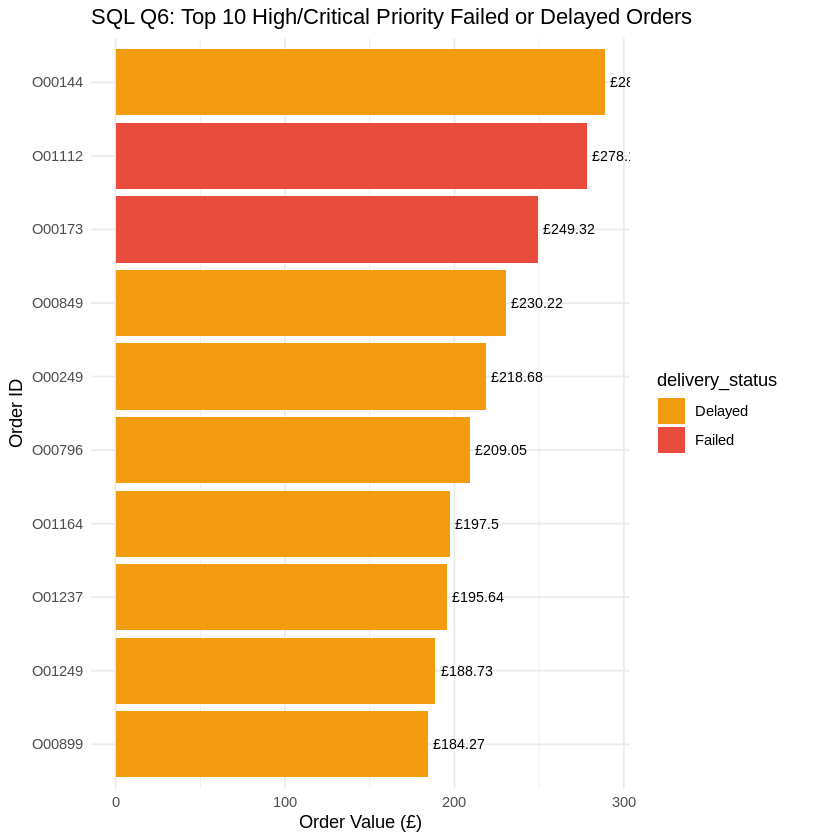

In [9]:
#SQL Query 6: High priority orders with delays
cat("\nQ6: High/Critical Priority Orders with Failed or Delayed Delivery\n")
q6 <- sqldf("SELECT o.order_id, o.service_type, o.priority_level,
             o.order_value, d.delivery_status
             FROM orders o
             JOIN deliveries d ON o.order_id = d.order_id
             WHERE o.priority_level IN ('High', 'Critical')
             AND d.delivery_status IN ('Failed', 'Delayed')
             ORDER BY o.order_value DESC
             LIMIT 10")
print(q6)

# Visualisation for SQL Q6: High Priority Failed/Delayed Orders
ggplot(q6, aes(x = reorder(order_id, order_value),
               y = order_value, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "SQL Q6: Top 10 High/Critical Priority Failed or Delayed Orders",
       x = "Order ID", y = "Order Value (£)") +
  theme_minimal() +
  scale_fill_manual(values = c("Delayed" = "#f39c12",
                                "Failed" = "#e74c3c")) +
  geom_text(aes(label = paste0("£", order_value)),
            hjust = -0.1, size = 3)


Q7: Complaints by Type and Average Resolution Days
     complaint_type total_complaints avg_resolution_days avg_compensation
1             Delay              101                7.26            18.05
2      MissedPickup               64                7.64            22.59
3          AppIssue               53                8.60            19.61
4   DriverBehaviour               51                8.16            21.15
5 SupportExperience               20                7.45            17.13
6           Billing               16                7.75            23.87
7            Damage               15               11.33            23.98


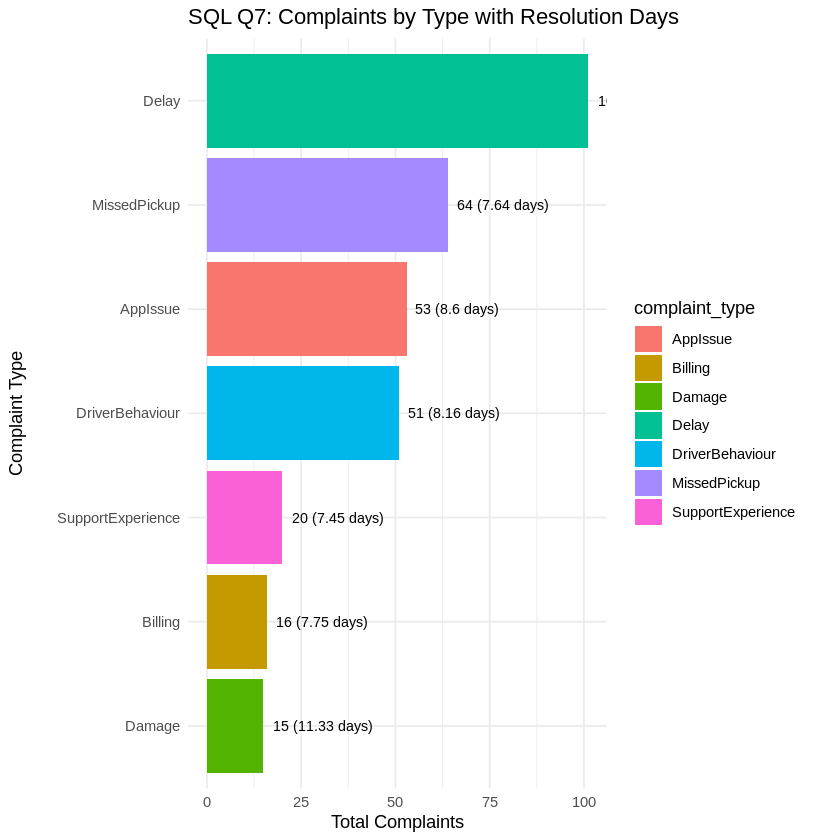

In [8]:
#SQL Query 7: Complaint types and resolution
cat("\nQ7: Complaints by Type and Average Resolution Days\n")
q7 <- sqldf("SELECT complaint_type,
             COUNT(*) AS total_complaints,
             ROUND(AVG(resolution_days), 2) AS avg_resolution_days,
             ROUND(AVG(compensation_amount), 2) AS avg_compensation
             FROM complaints
             GROUP BY complaint_type
             ORDER BY total_complaints DESC")
print(q7)

ggplot(q7, aes(x = reorder(complaint_type, total_complaints),
               y = total_complaints, fill = complaint_type)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "SQL Q7: Complaints by Type with Resolution Days",
       x = "Complaint Type", y = "Total Complaints") +
  theme_minimal() +
  geom_text(aes(label = paste0(total_complaints, " (", avg_resolution_days, " days)")),
            hjust = -0.1, size = 3)

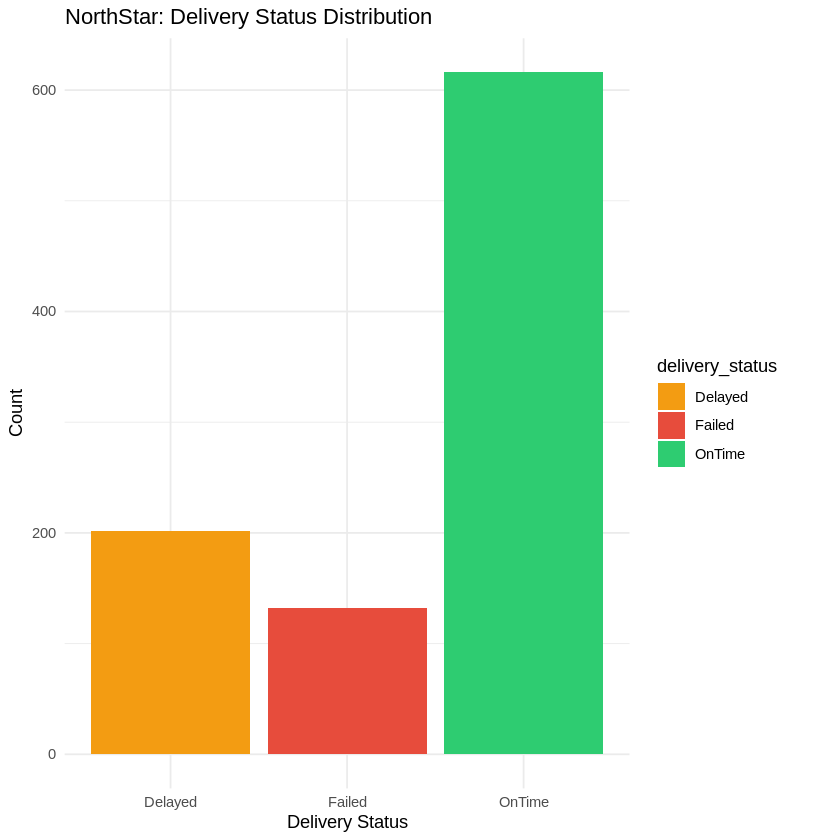

In [ ]:
# Visualisation 1: Delivery status distribution
ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  labs(title = "NorthStar: Delivery Status Distribution",
       x = "Delivery Status", y = "Count") +
  theme_minimal() +
  scale_fill_manual(values = c("OnTime" = "#2ecc71",
                                "Delayed" = "#f39c12",
                                "Failed" = "#e74c3c"))

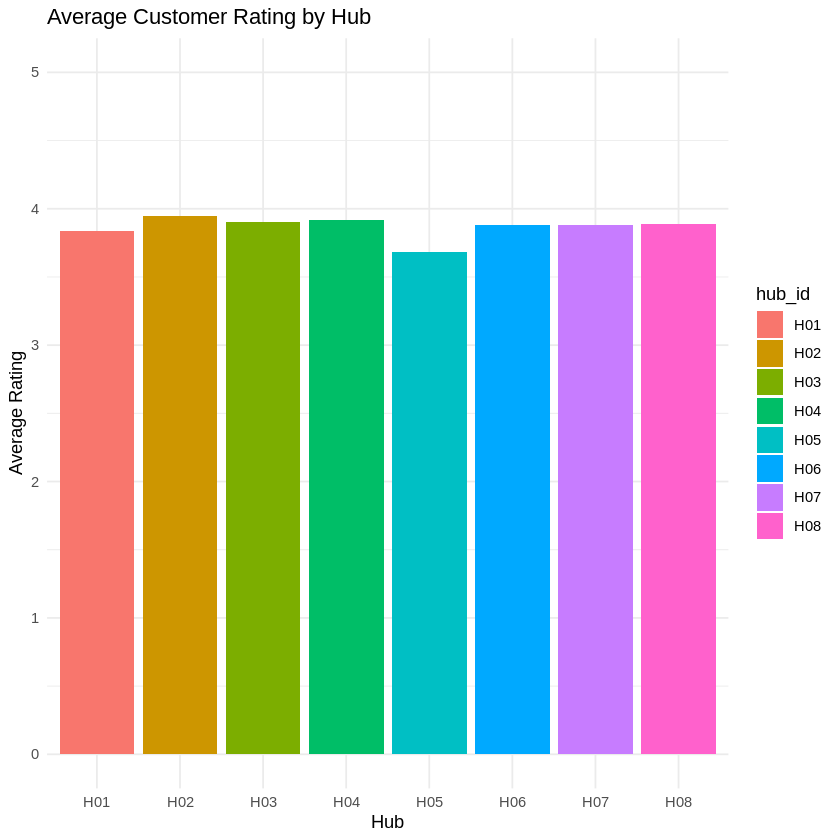

In [ ]:
# Visualisation 2: Average customer rating per hub
hub_ratings <- deliveries %>%
  group_by(hub_id) %>%
  summarise(avg_rating = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2))

ggplot(hub_ratings, aes(x = hub_id, y = avg_rating, fill = hub_id)) +
  geom_bar(stat = "identity") +
  labs(title = "Average Customer Rating by Hub",
       x = "Hub", y = "Average Rating") +
  theme_minimal() +
  ylim(0, 5)

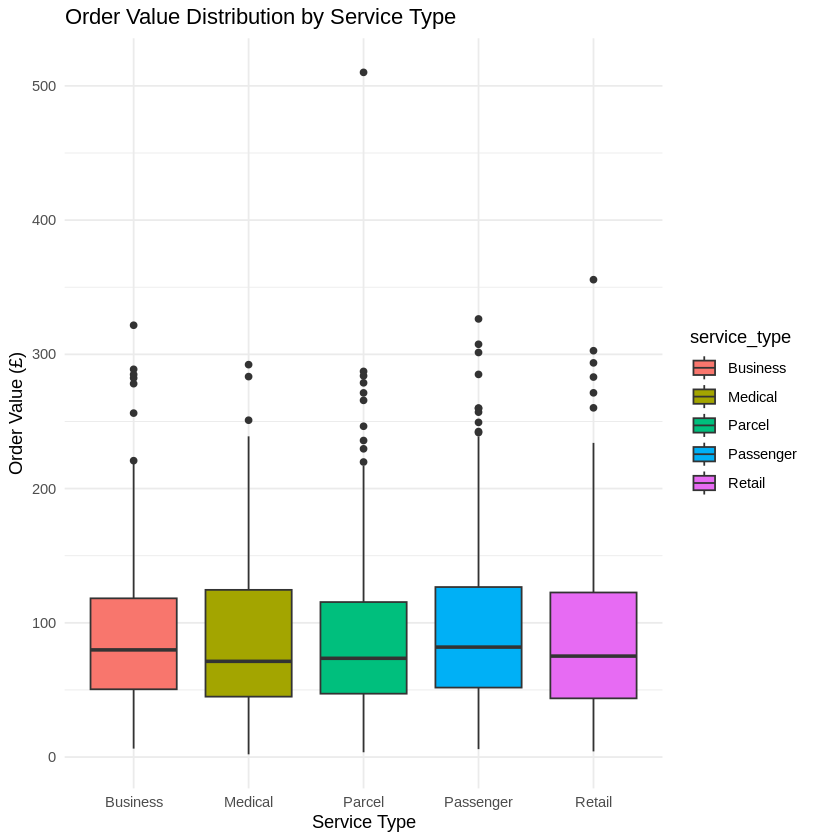

In [ ]:
# Visualisation 3: Order value distribution by service type
ggplot(orders, aes(x = service_type, y = order_value, fill = service_type)) +
  geom_boxplot() +
  labs(title = "Order Value Distribution by Service Type",
       x = "Service Type", y = "Order Value (£)") +
  theme_minimal()

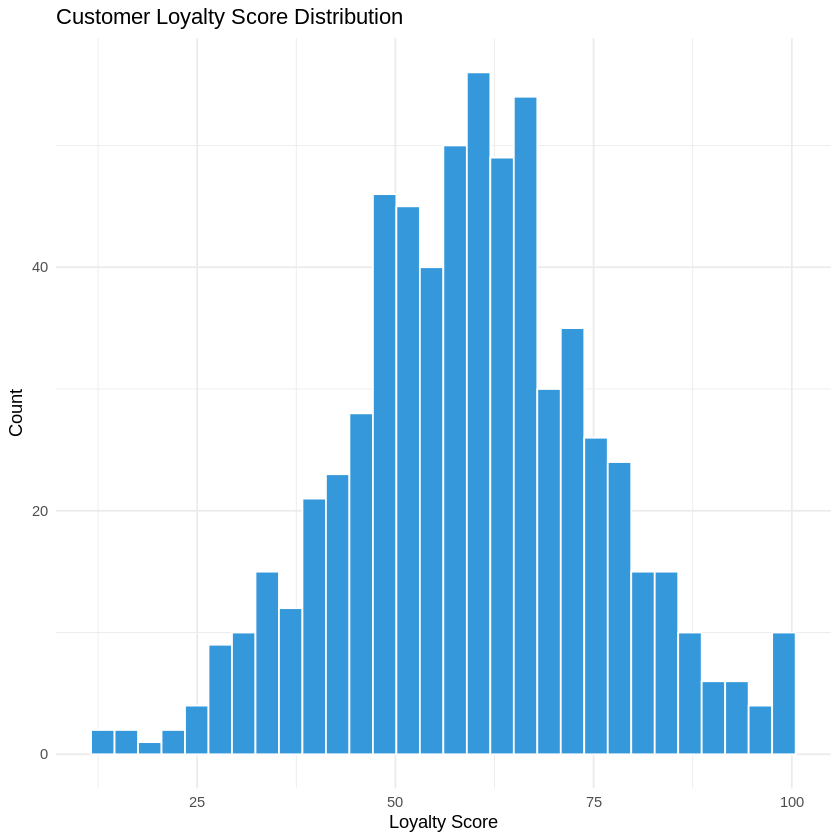

In [ ]:
# Visualisation 4: Customer loyalty score distribution
ggplot(customers, aes(x = loyalty_score)) +
  geom_histogram(bins = 30, fill = "#3498db", color = "white") +
  labs(title = "Customer Loyalty Score Distribution",
       x = "Loyalty Score", y = "Count") +
  theme_minimal()

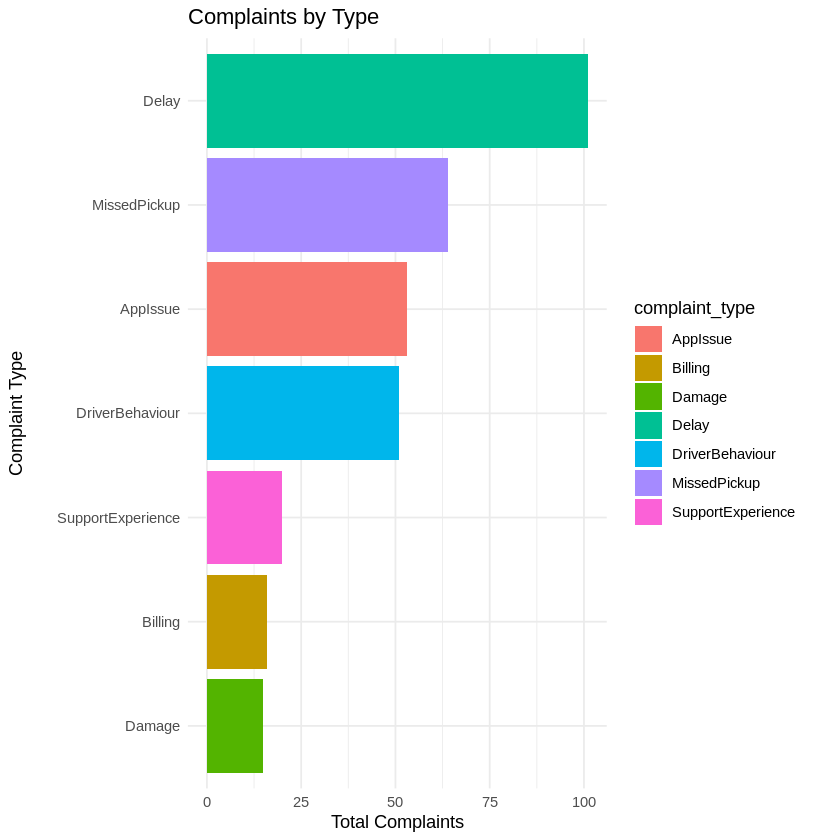

In [ ]:
# Visualisation 5: Total complaints by type
complaint_summary <- complaints %>%
  group_by(complaint_type) %>%
  summarise(total = n()) %>%
  arrange(desc(total))

ggplot(complaint_summary, aes(x = reorder(complaint_type, total),
                               y = total, fill = complaint_type)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Complaints by Type",
       x = "Complaint Type", y = "Total Complaints") +
  theme_minimal()

Correlation: Loyalty Score vs App Engagement



	Pearson's product-moment correlation

data:  customers$loyalty_score and customers$app_engagement_score
t = 0.8944, df = 628, p-value = 0.3715
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.04256479  0.11346559
sample estimates:
       cor 
0.03566776 


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”



Mean Order Value by Priority Level
# A tibble: 4 × 3
  priority_level mean_value count
  <chr>               <dbl> <int>
1 High                 95.7   308
2 Medium               90.2   503
3 Critical             89.4    91
4 Low                  88.7   348


Warning message in geom_text(aes(label = paste0("£", mean_value)), vmin = -0.3, :
“Ignoring unknown parameters: `vmin`”


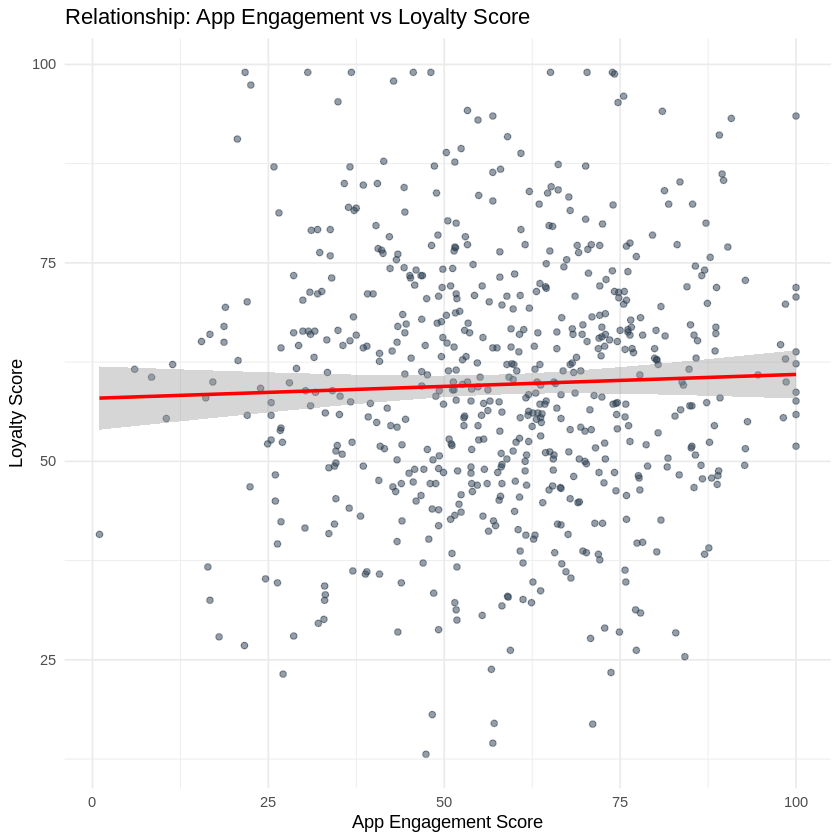

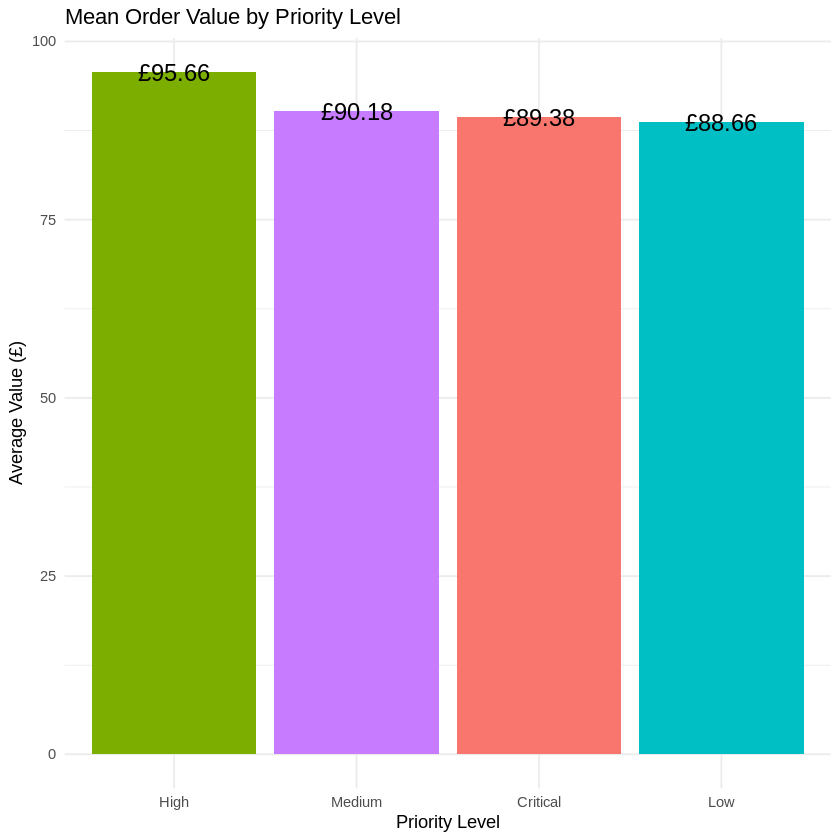

In [16]:
# Statistical Analysis: Correlation between loyalty and engagement
cat("Correlation: Loyalty Score vs App Engagement\n")
cor.test(customers$loyalty_score, customers$app_engagement_score)

# This shows the relationship between Engagement and Loyalty
ggplot(customers, aes(x = app_engagement_score, y = loyalty_score)) +
  geom_point(alpha = 0.5, color = "#2c3e50") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Relationship: App Engagement vs Loyalty Score",
       x = "App Engagement Score", y = "Loyalty Score") +
  theme_minimal()

# Mean order value by priority level
cat("\nMean Order Value by Priority Level\n")
orders %>%
  group_by(priority_level) %>%
  summarise(mean_value = round(mean(order_value), 2),
            count = n()) %>%
  arrange(desc(mean_value)) %>%
  print()


priority_stats <- orders %>%
  group_by(priority_level) %>%
  summarise(mean_value = round(mean(order_value), 2))

ggplot(priority_stats, aes(x = reorder(priority_level, -mean_value), y = mean_value, fill = priority_level)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0("£", mean_value)), vmin = -0.3, size = 5) +
  labs(title = "Mean Order Value by Priority Level",
       x = "Priority Level", y = "Average Value (£)") +
  theme_minimal() +
  guides(fill = "none")
